In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('Churn_Modelling.csv')    
print(df.info())
print()
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None

         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000

<Axes: xlabel='Exited'>

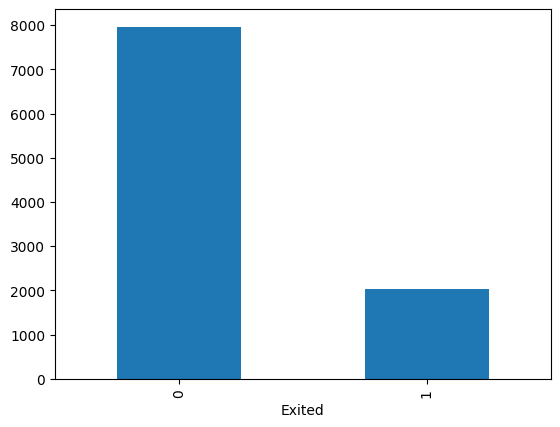

In [3]:
df['Exited'].value_counts().plot(kind='bar')

<Axes: xlabel='Geography'>

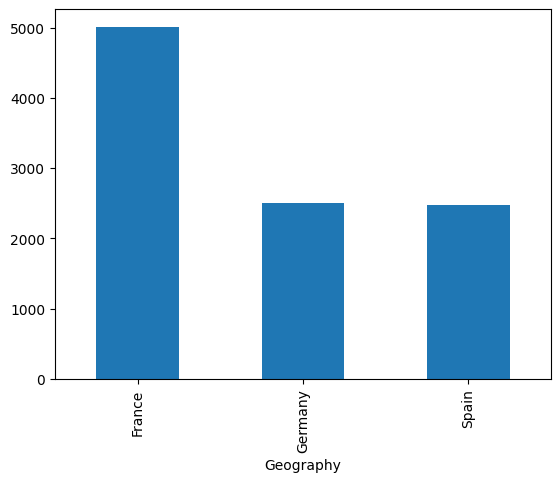

In [4]:
df['Geography'].value_counts().plot(kind='bar')

<Axes: xlabel='Gender'>

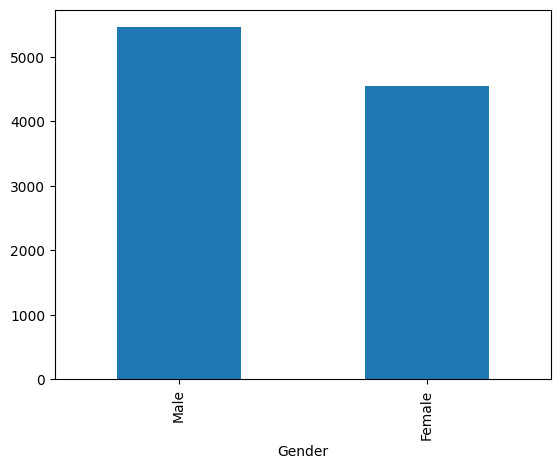

In [5]:
df.Gender.value_counts().plot(kind='bar')

In [6]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)


In [7]:
df.columns        

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

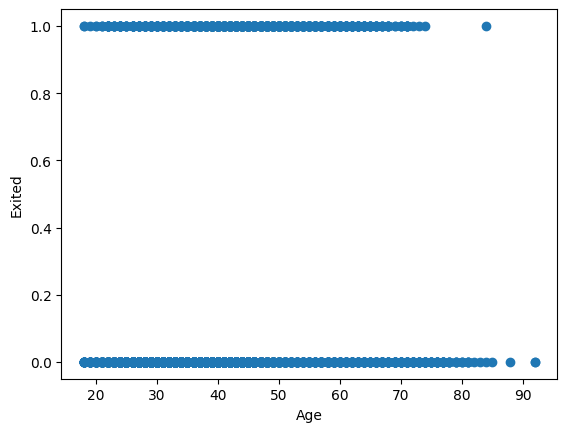

In [8]:
plt.scatter(df.Age, df.Exited)
plt.xlabel('Age')
plt.ylabel('Exited')
plt.show()

In [9]:
df = pd.get_dummies(df,columns=['Geography', 'Gender'], drop_first=True)

In [10]:
from sklearn.model_selection import train_test_split
X = df.drop('Exited', axis=1)
y = df.Exited
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(11, 3),   # input_dim=11 -> units=3
    nn.Sigmoid(),       # activation='sigmoid'
    nn.Linear(3, 1),    # units=3 -> units=1
    nn.Sigmoid()        # activation='sigmoid'
)

In [31]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=50, shuffle=True)

history = {'loss': [], 'accuracy': []}

for epoch in range(100):
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)
        preds = (outputs >= 0.5).float()
        epoch_correct += (preds == yb).sum().item()
        epoch_total += xb.size(0)

    epoch_loss /= epoch_total
    epoch_acc = epoch_correct / epoch_total
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/100, Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}')

model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred = (y_pred >= 0.5).int()



Epoch 10/100, Loss: 0.3759, Acc: 0.8510
Epoch 20/100, Loss: 0.3735, Acc: 0.8512
Epoch 30/100, Loss: 0.3716, Acc: 0.8516
Epoch 40/100, Loss: 0.3697, Acc: 0.8505
Epoch 50/100, Loss: 0.3679, Acc: 0.8504
Epoch 60/100, Loss: 0.3663, Acc: 0.8515
Epoch 70/100, Loss: 0.3648, Acc: 0.8515
Epoch 80/100, Loss: 0.3635, Acc: 0.8519
Epoch 90/100, Loss: 0.3624, Acc: 0.8542
Epoch 100/100, Loss: 0.3612, Acc: 0.8539


In [32]:
Y_test_tensor = torch.tensor(y_test.values, dtype=torch.int)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_test_tensor, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1607
           1       0.70      0.41      0.52       393

    accuracy                           0.85      2000
   macro avg       0.79      0.68      0.72      2000
weighted avg       0.84      0.85      0.83      2000



Text(0, 0.5, 'Loss')

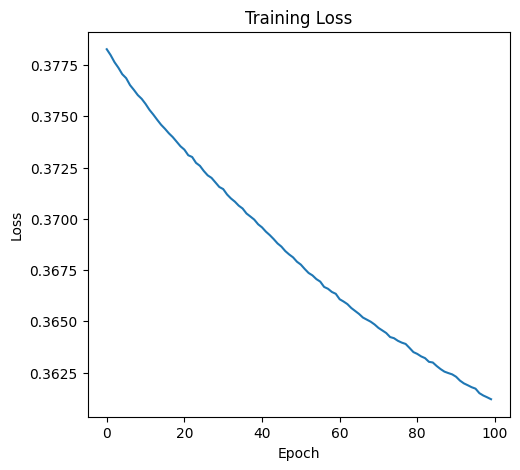

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')